# El certificado computable

Sesión del 9 de julio de 2026. El orden del cuaderno es el arco de la
conversación: primero el rigor (una corrección al Gibbs, probada en vivo),
después el resultado nuevo (la primera cota penalizada del problema), luego
la figura que une las tres direcciones, y al final la dirección que todo esto
sostiene. Cada número se regenera aquí o se lee de un CSV versionado; no hay
cifras escritas a mano.


In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import random, math
import pandas as pd
import matplotlib.pyplot as plt

import augmented
ROOT = os.path.dirname(os.path.dirname(os.path.abspath(augmented.__file__)))
DATA = os.path.join(ROOT, 'augmented', 'data')
FIGS = os.path.join(ROOT, 'augmented', 'figures')
print('repo:', ROOT)

repo: /Users/hectorbecerrilvillamil/Desktop/GroupCounting/group-count-dynamic


## 1. El Gibbs necesitaba una segunda corrección

Un muestreador MCMC necesita dos propiedades distintas. La corrección de
junio arregló la primera (irreducibilidad: la cadena llega a todos los
estados). La auditoría del 6 de julio encontró que la segunda seguía rota:
el equilibrio detallado. La propuesta por caminos alternantes es asimétrica
—el número de parejas elegibles en cada reparación difiere entre el estado de
salida y el de llegada— y la aceptación usaba solo el cociente de priors,
que exige propuesta simétrica. Resultado: una cadena que recorre todo, es
estable entre semillas, y converge a la posterior equivocada.

La celda siguiente lo demuestra en vivo sobre el contraejemplo mínimo
(tests $\{0,1,2\}=1$ y $\{2,3,4\}=1$, priors heterogéneos): corre la MISMA
propuesta dos veces, una aceptando solo con el ratio de priors (el bug) y
otra con el factor de Hastings del camino espejo (la corrección), contra la
posterior exacta por enumeración.

In [2]:
from augmented.core import mask_from_indices
from augmented.bayesian import (bayesian_update_by_counting,
                                _propose_alternating_move, _find_valid_state)

p = [0.1, 0.3, 0.5, 0.7, 0.9]
history = ((mask_from_indices([0, 1, 2]), 1), (mask_from_indices([2, 3, 4]), 1))
n = 5
exact = bayesian_update_by_counting(p, history, n)

comp = list(range(n))
tests = [([0, 1, 2], 1), ([2, 3, 4], 1)]
agent_tests = {a: [] for a in comp}
for ti, (members, r) in enumerate(tests):
    for a in members:
        agent_tests[a].append(ti)

def run_chain(use_hastings, iters=60000, burn=5000, seed=0):
    rng = random.Random(seed)
    remaining = [(mask_from_indices(m), r) for m, r in tests]
    state = _find_valid_state(remaining, comp, p, rng)
    counts = [0] * n
    draws = 0
    for it in range(iters):
        prop = _propose_alternating_move(comp, tests, agent_tests, state,
                                         rng, max_steps=42)
        if prop is not None:
            move, log_corr = prop
            log_ratio = log_corr if use_hastings else 0.0
            ok = True
            for a, nv in move.items():
                ov = state[a]
                if nv == ov:
                    continue
                num = p[a] if nv == 1 else 1.0 - p[a]
                den = p[a] if ov == 1 else 1.0 - p[a]
                if num <= 0:
                    ok = False; break
                log_ratio += math.log(num) - math.log(den)
            if ok and (log_ratio >= 0 or rng.random() < math.exp(log_ratio)):
                state.update(move)
        if it >= burn:
            for a in comp:
                counts[a] += state[a]
            draws += 1
    return [c / draws for c in counts]

sin_h = run_chain(use_hastings=False)
con_h = run_chain(use_hastings=True)
df = pd.DataFrame({'exacta': exact, 'sin Hastings (bug)': sin_h,
                   'con Hastings (fix)': con_h})
df.index.name = 'agente'
err_sin = max(abs(a - b) for a, b in zip(sin_h, exact))
err_con = max(abs(a - b) for a, b in zip(con_h, exact))
print(df.round(4))
print(f"\nerror máximo sin Hastings: {err_sin:.4f}   con Hastings: {err_con:.4f}")

        exacta  sin Hastings (bug)  con Hastings (fix)
agente                                                
0       0.1770              0.1652              0.1803
1       0.6825              0.6283              0.6818
2       0.1405              0.2065              0.1378
3       0.1770              0.1616              0.1746
4       0.6825              0.6318              0.6876

error máximo sin Hastings: 0.0660   con Hastings: 0.0050


La versión sin corrección no está "poco convergida": está convergida al
lugar equivocado (el error ~0.07 es estable entre semillas e iteraciones).
La prueba formal fue más fuerte que esta demostración estadística: se
enumeraron todas las ramas del generador aleatorio para construir la matriz
de transición exacta de la cadena implementada; su estacionaria quedó a
distancia TV 0.067 de la posterior, y la de la cadena corregida a 0.000000,
en las cinco topologías auditadas. Los resultados previos (n ≤ 14) nunca
tocaron esta rama; la escalada del Gibbs a n = 30–50 ahora descansa sobre una
cadena correcta. De paso quedan atendidas las dos indicaciones de la reunión
pasada: las distancias se midieron en TV, y hay una cadena válida sobre la
cual estudiar mixing.

## 2. La primera cota penalizada

El óptimo es incalculable más allá de $n=14$, así que certificar una política
exige acotarlo por arriba. La cota hindsight $U_{PI}$ (el adversario que
conoce $Z$ limpia a las $B\cdot G$ personas limpias de mayor utilidad) es
válida a cualquier escala pero floja: el adversario es demasiado fuerte. La
técnica estándar para apretarla —relajación de información con penalización,
Brown–Smith–Sun— le cobra al adversario una multa por usar información
futura: la diferencia entre el valor estimado tras ver el resultado y su
esperanza antes de verlo, medida con una función de valor aproximada
$\hat V$. El teorema: para CUALQUIER $\hat V$ la cota sigue siendo válida;
solo la tightness depende de elegir bien. Nadie había aplicado esto a
adquisición adaptativa de información combinatoria.

Primero una instancia en vivo, con la validez verificada contra el óptimo
exacto:

In [3]:
from augmented.solver import solve_optimal_dapts
from augmented.greedy import greedy_myopic_expected_utility
from augmented.certificates import u_pi_exact, u_pen_exact

p_i = [0.3, 0.4, 0.5, 0.25, 0.6]
u_i = [3.0, 1.0, 2.0, 4.0, 2.5]
B, G = 2, 3
opt, _ = solve_optimal_dapts(p_i, u_i, B, G)
grd = greedy_myopic_expected_utility(p_i, u_i, B, G)
upi = u_pen_zero = u_pi_exact(p_i, u_i, B, G)
upen = u_pen_exact(p_i, u_i, B, G, v_hat='umax')
assert upen >= opt - 1e-9, 'la cota dejó de ser válida'
print(f"OPT = {opt:.4f}   greedy = {grd:.4f}")
print(f"U_PI = {upi:.4f}  -> certifica {grd/upi:.1%}")
print(f"U_pen = {upen:.4f} -> certifica {grd/upen:.1%}")

OPT = 5.1750   greedy = 5.1750
U_PI = 7.7000  -> certifica 67.2%
U_pen = 7.5056 -> certifica 68.9%


Y la tabla completa (106 instancias, `data/certificates_small_n.csv`,
cero violaciones de validez):

In [4]:
cert = pd.read_csv(os.path.join(DATA, 'certificates_small_n.csv'))
tabla = (cert.groupby(['n', 'B', 'G'])
             [['true_ratio', 'cert_pi', 'cert_pen']]
             .mean().round(3))
tabla.columns = ['greedy/OPT (real)', 'certificado U_PI', 'certificado U_pen']
tabla['apriete'] = (tabla['certificado U_pen'] - tabla['certificado U_PI']).round(3)
print(tabla)

       greedy/OPT (real)  certificado U_PI  certificado U_pen  apriete
n B G                                                                 
4 2 2              0.984             0.794              0.843    0.049
    3              0.980             0.790              0.790    0.000
5 2 3              0.986             0.702              0.731    0.029
  3 3              0.935             0.822              0.822    0.000
6 2 3              0.981             0.631              0.683    0.052
  3 3              0.927             0.764              0.764    0.000

Tres lecturas. Primera: el greedy real está entre 0.93 y 0.99 del óptimo,
pero lo demostrable ronda 0.7 — el cuello de botella del programa es la
demostración, no el algoritmo. Segunda: la penalización funciona (+4 a +5
puntos), primera vez que algo aprieta la hindsight en este problema.
Tercera, la mejor: el apriete es un fenómeno de horizonte — todo el efecto
vive en $B=2$ y muere en $B=3$, calcando la ley del lookahead (99% → 40% →
16%). La penalización con $\hat V$ miope se comporta como anticipación de un
paso.

Hubo además un experimento fallido instructivo: la $\hat V$ sofisticada (el
valor a futuro del propio greedy) certifica PEOR que el potencial simple,
porque alimenta marginales al greedy como si fueran priors independientes y
el adversario interno explota sistemáticamente ese sesgo. Es el independence
gap atacando al certificado: la $\hat V$ buena es insesgada antes que
precisa.

## 3. El mapa con garantías

Las tres perillas del paper en un solo objeto. Por cada punto $(B, \text{cap})$:
la fracción del valor que es real (la curva de resolución, solo computable en
$n$ chico) y la que es certificable a cualquier escala. La banda entre ambas
es, literalmente, el programa de investigación.

    real_frac           cert_frac              
cap         1    2    3         1      2      3
B                                              
1       1.000  1.0  1.0     0.576  0.576  0.576
2       0.989  1.0  1.0     0.646  0.653  0.653
3       0.935  1.0  1.0     0.794  0.848  0.848


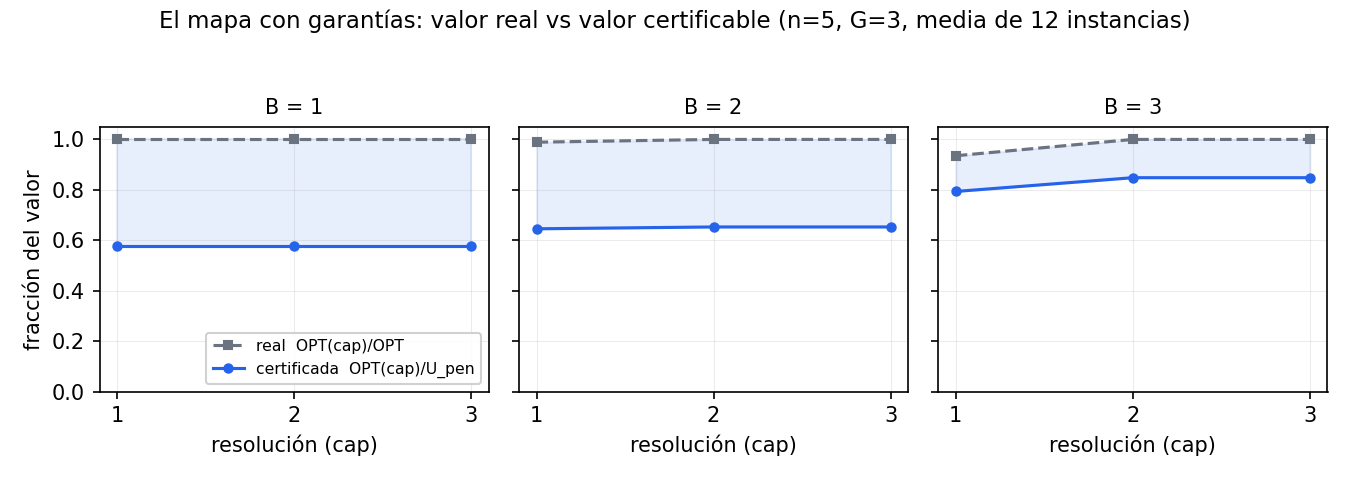

In [5]:
cmap = pd.read_csv(os.path.join(DATA, 'certified_map.csv'))
resumen = (cmap.groupby(['B', 'cap'])[['real_frac', 'cert_frac']]
               .mean().round(3).unstack('cap'))
print(resumen)

from IPython.display import Image, display
display(Image(filename=os.path.join(FIGS, 'certified_map.png')))

Dos datos que la figura deja ver. La fracción certificada crece con el
horizonte (0.58 en $B=1$ → 0.85 en $B=3$): el certificado mejora justo donde
el problema se vuelve interesante. Y en $B=3$ el canal de tres niveles
certifica exactamente lo mismo que el conteo completo (0.85 en cap 2 y 3,
contra 0.79 del binario): la versión certificada del resultado del 84.5% —
el canal barato no pierde nada demostrable.

## 4. La dirección

El mapa dice cuándo la información vale, gobernado por horizonte, estructura
y resolución. La dirección propia agrega el eje que el mapa no nombra: cuánto
de ese valor es reclamable y certificable con cómputo finito. El objeto que
lo mide es el certificado, y con ese lente las tres direcciones son
rebanadas de una sola cantidad: D3 es el certificado mismo; D1 dice cuándo su
capa de inferencia es computable (la dureza #P, el mixing del Gibbs — ahora
sobre una cadena correcta); D2 es el certificado aplicado al canal, con su
primer punto de dato en la sección anterior. El descubrimiento del horizonte
reaparece del lado de las cotas en el patrón del apriete.

En una frase: el mapa dice cuándo contar vale; esta línea caracteriza cuánto
de ese valor se puede reclamar y certificar con cómputo finito, como función
de las tres perillas.

## 5. En la recámara: el motor vestido de producto

La traducción literal a evaluación de flotas de agentes (los evals por lotes
son pools; el grader reporta cuántas fallas, no cuáles). Versión reducida de
`demo_fleet_certification.py` (la completa usa 300 simulaciones):

In [6]:
from augmented.demo_fleet_certification import (build_fleet, selector,
                                                random_selector, mc_value,
                                                B as FB, G as FG)
from augmented.certificates import u_pi_mc

rng = random.Random(7)
names, fp, fu = build_fleet(rng)
mean_g, se_g = mc_value(fp, fu, selector, 80, seed=100)
mean_r, se_r = mc_value(fp, fu, random_selector(random.Random(3)), 80, seed=100)
upi50 = u_pi_mc(fp, fu, FB, FG, num_samples=60000, seed=0)
print(f"flota n=50, presupuesto {FB} corridas por lotes (<= {FG} por lote)")
print(f"motor:     {mean_g:7.2f} +- {se_g:.2f}  -> certifica >= {mean_g/upi50:.0%} del óptimo")
print(f"aleatorio: {mean_r:7.2f} +- {se_r:.2f}  -> {mean_r/upi50:.0%}")
print(f"cota U_PI: {upi50:7.2f}")

flota n=50, presupuesto 10 corridas por lotes (<= 5 por lote)
motor:      177.68 +- 4.01  -> certifica >= 77% del óptimo
aleatorio:  105.48 +- 4.66  -> 46%
cota U_PI:  231.25


## 6. Tres preguntas para trabajar juntos

Primera, la $\hat V$ correcta para la penalización. La evidencia impone dos
condiciones: insesgada donde el adversario mira, y con alcance que crezca con
el horizonte. ¿Existe una familia de $\hat V$ con profundidad $d(B)$ cuyo
problema interno se descomponga, para dar el primer certificado apretado en
$n=50$? (Hoy: 58% con hindsight puro.)

Segunda, el conteo con ruido como cuarta perilla del mapa: si el test reporta
$r$ con error —el cycle threshold de counting, el grader LLM que se equivoca—,
¿cómo se degrada la escalera de resolución?

Tercera, el mixing time del Gibbs corregido como función del grado $K$ del
hipergrafo: el puente entre D1 y la capa de inferencia del certificado, ahora
que la cadena es válida y se puede estudiar con las herramientas estándar
(Levin–Peres).